## Examine how the temperatures at upper and lower stations are changing over time

# Temperature Analysis - comparing upper and lower stations for seasonality

Temperature Change for upper and lower stations for Summer (JJA)

In [2]:
import pandas as pd
import numpy as np
import pymannkendall as mk
from pathlib import Path

# ── Settings ────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
RESULTS_DIR = PROJECT_ROOT / "Results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SITES = ["KAN", "NUK", "QAS", "THU", "SCO"]

# ── Season extraction ────────────────────────────────────────────────────────
def get_season_series(df, season):

    if season == "DJF":
        df = df[df["time"].dt.month.isin([12, 1, 2])]

        # winter year
        df["year"] = np.where(
            df["time"].dt.month == 12,
            df["time"].dt.year + 1,
            df["time"].dt.year
        )

    elif season == "JJA":
        df = df[df["time"].dt.month.isin([6, 7, 8])]
        df["year"] = df["time"].dt.year

    else:
        raise ValueError("Use DJF or JJA")

    # seasonal mean per year
    return df.groupby("year")["t_u"].mean().dropna()


# ── MK analysis function ─────────────────────────────────────────────────────
def run_mk(series):

    result = mk.original_test(series)

    return {
        "trend": result.trend,
        "p": result.p,
        "tau": result.Tau,
        "slope": result.slope
    }


# ── Main loop ────────────────────────────────────────────────────────────────
results = []

for site in SITES:

    path_u = DATA_DIR / f"{site}_U_month_clean.csv"
    path_l = DATA_DIR / f"{site}_L_month_clean.csv"

    for position, path in [("U", path_u), ("L", path_l)]:

        df = pd.read_csv(path, parse_dates=["time"])

        for season in ["DJF", "JJA"]:

            series = get_season_series(df.copy(), season)

            if len(series) < 5:
                continue

            mk_res = run_mk(series)

            results.append({
                "site": site,
                "station": position,
                "season": season,
                "n_years": len(series),
                "trend": mk_res["trend"],
                "p_value": mk_res["p"],
                "tau": mk_res["tau"],
                "sen_slope": mk_res["slope"]
            })


# ── Results table ────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)

print("\n📊 Mann-Kendall + Sen slope results:\n")
print(results_df.sort_values(["site", "season", "station"]))

# Optional save
results_df.to_csv(RESULTS_DIR / "MK_Sen_results_DJF_JJA.csv", index=False)
print("✅ Saved: Results/MK_Sen_results_DJF_JJA.csv")


📊 Mann-Kendall + Sen slope results:

   site station season  n_years       trend   p_value       tau  sen_slope
2   KAN       L    DJF       17    no trend  0.650463 -0.088235  -0.075967
0   KAN       U    DJF       16    no trend  0.444044 -0.150000  -0.109548
3   KAN       L    JJA       16    no trend  0.052872 -0.366667  -0.077174
1   KAN       U    JJA       16    no trend  0.260351 -0.216667  -0.092842
6   NUK       L    DJF       13    no trend  0.669334  0.102564   0.096522
4   NUK       U    DJF       15    no trend  0.921159  0.028571   0.012567
7   NUK       L    JJA       15    no trend  0.373053 -0.180952  -0.042790
5   NUK       U    JJA       16    no trend  0.344418 -0.183333  -0.039482
10  QAS       L    DJF       17    no trend  0.967142 -0.014706  -0.012840
8   QAS       U    DJF       16    no trend  0.444044 -0.150000  -0.124413
11  QAS       L    JJA       16    no trend  0.162805  0.266667   0.041034
9   QAS       U    JJA       14    no trend  0.742557  0.07692

## Winter Temperature at all Stations 

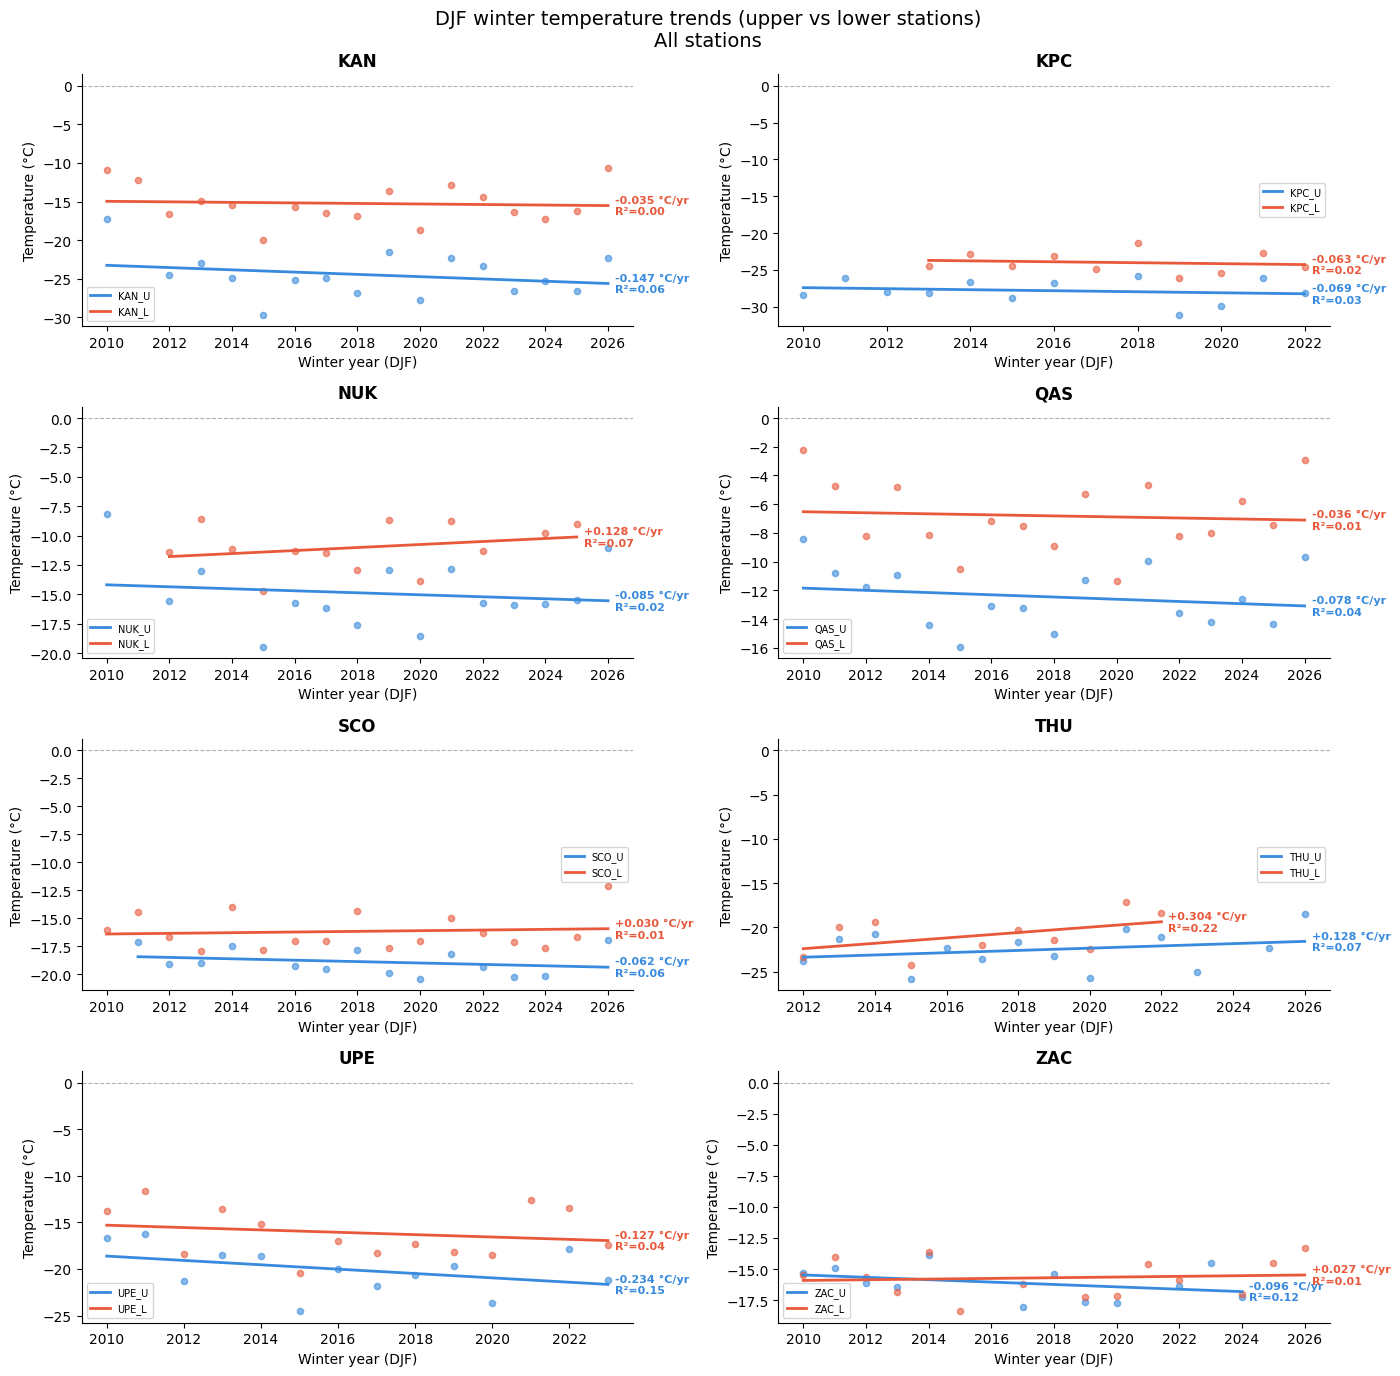

✅ Saved: c:\Users\miria\Documents\UNI\4_Semester\SEMINAR_PHY\SE_402.212_GreenlandTemperature\Figures\DJF_all_stations_trends.png


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
FIGURE_DIR = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Stations ──────────────────────────────────────────────────────────────────
SITES = ["KAN", "KPC", "NUK", "QAS", "SCO", "THU", "UPE", "ZAC"]

COLOR_UPPER = "#378ADD"
COLOR_LOWER = "#E8593C"


# ── DJF aggregation ───────────────────────────────────────────────────────────
def load_djf(site, position):

    path = DATA_DIR / f"{site}_{position}_month_clean.csv"
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.sort_values("time")

    # DJF only
    df = df[df["time"].dt.month.isin([12, 1, 2])]
    df = df.dropna(subset=["t_u"])

    # winter year
    df["winter_year"] = np.where(
        df["time"].dt.month == 12,
        df["time"].dt.year + 1,
        df["time"].dt.year
    )

    # mean per winter
    return df.groupby("winter_year")["t_u"].mean().reset_index()


# ── Trend helper ──────────────────────────────────────────────────────────────
def add_trend(ax, df, color, label):

    x = df["winter_year"].to_numpy()
    y = df["t_u"].to_numpy()

    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b

    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

    ax.plot(x, y_pred, color=color, linewidth=2, label=label)

    ax.annotate(
        f"{m:+.3f} °C/yr\nR²={r2:.2f}",
        xy=(x[-1], y_pred[-1]),
        xytext=(5, 0),
        textcoords="offset points",
        color=color,
        fontsize=8,
        fontweight="bold",
        ha="left",
        va="center"
    )


# ── Plot setup ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()


for ax, site in zip(axes, SITES):

    try:
        upper = load_djf(site, "U")
        lower = load_djf(site, "L")
    except Exception:
        ax.set_title(f"{site} (missing data)")
        ax.axis("off")
        continue

    if len(upper) < 3 or len(lower) < 3:
        ax.set_title(f"{site} (insufficient data)")
        ax.axis("off")
        continue

    # Scatter
    ax.scatter(upper["winter_year"], upper["t_u"],
               color=COLOR_UPPER, alpha=0.6, s=20)

    ax.scatter(lower["winter_year"], lower["t_u"],
               color=COLOR_LOWER, alpha=0.6, s=20)

    # Trends
    add_trend(ax, upper, COLOR_UPPER, f"{site}_U")
    add_trend(ax, lower, COLOR_LOWER, f"{site}_L")

    # Formatting
    ax.set_title(site, fontweight="bold")
    ax.set_xlabel("Winter year (DJF)")
    ax.set_ylabel("Temperature (°C)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(fontsize=7, loc="best")


# Hide empty axes if any
for ax in axes[len(SITES):]:
    ax.axis("off")


fig.suptitle(
    "DJF winter temperature trends (upper vs lower stations)\nAll stations",
    fontsize=14
)

fig.tight_layout()

output_path = FIGURE_DIR / "DJF_all_stations_trends.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"✅ Saved: {output_path}")

## Summer Temperatures all stations JJA 

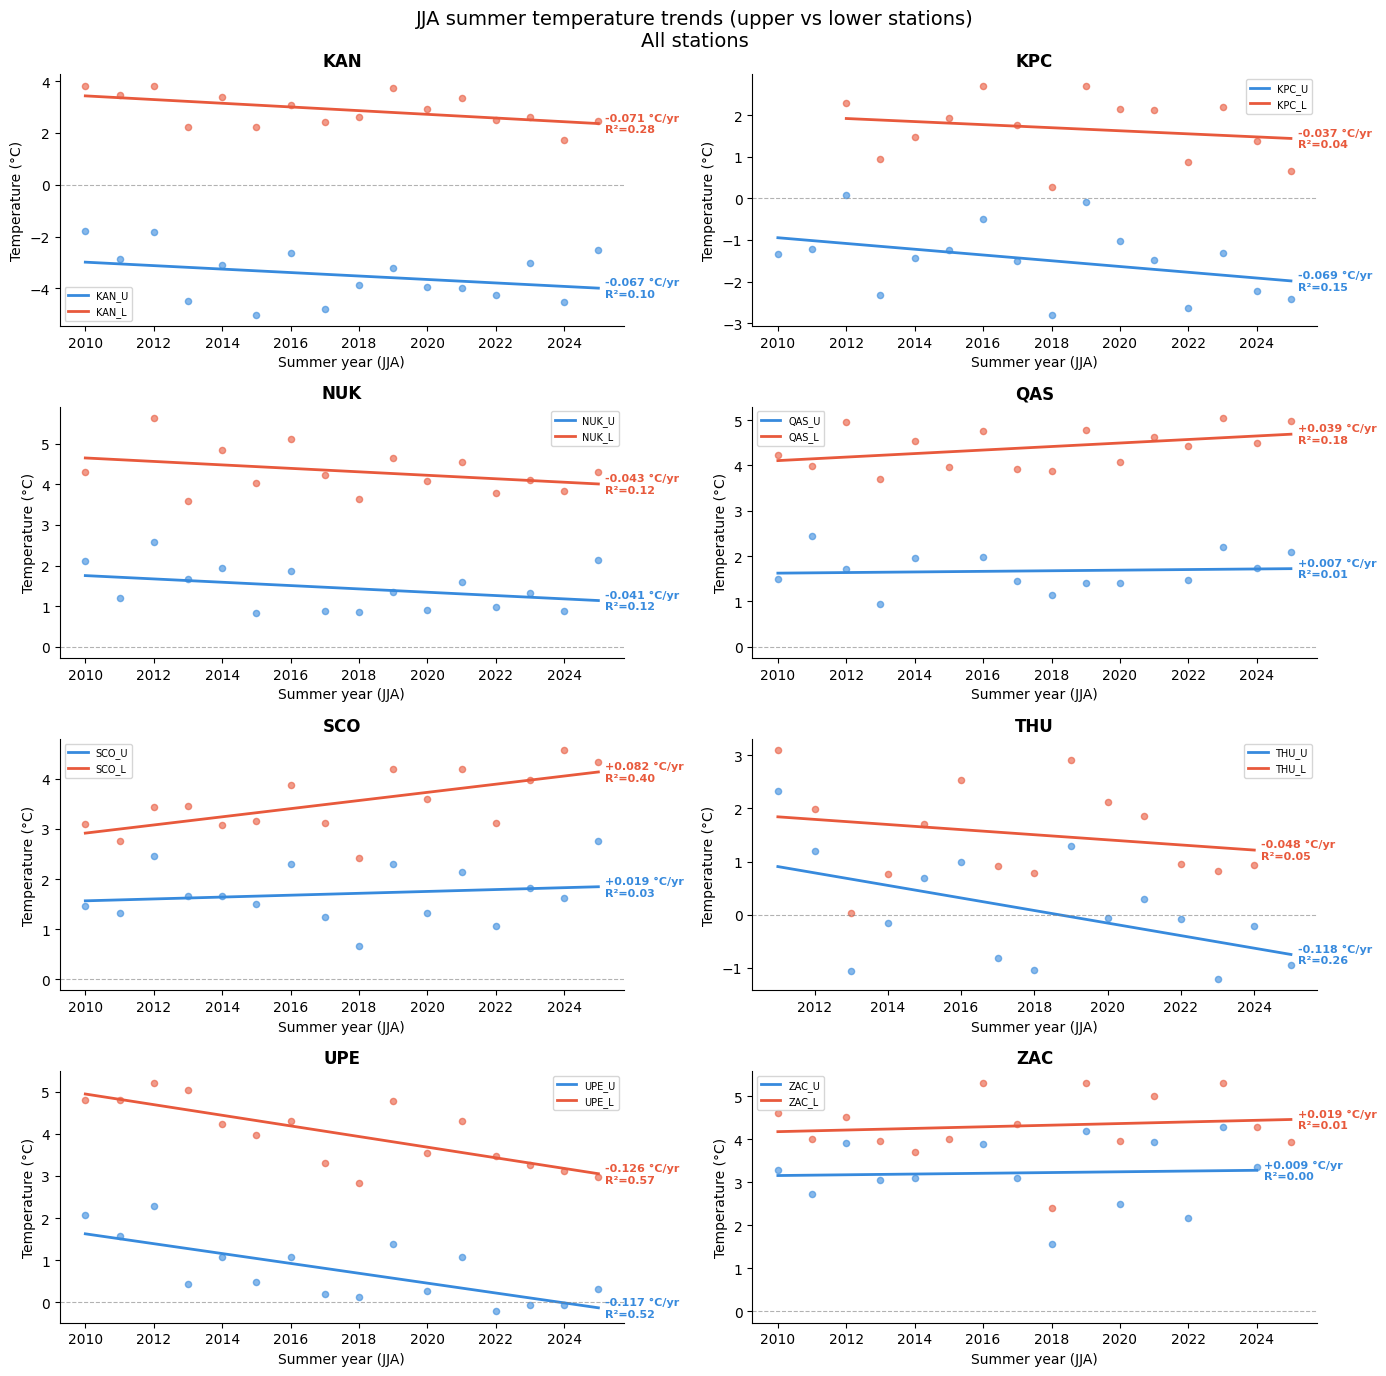

✅ Saved: c:\Users\miria\Documents\UNI\4_Semester\SEMINAR_PHY\SE_402.212_GreenlandTemperature\Figures\JJA_all_stations_trends.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "Data_Processed" / "Cleaned_Stations"
FIGURE_DIR = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Stations ──────────────────────────────────────────────────────────────────
SITES = ["KAN", "KPC", "NUK", "QAS", "SCO", "THU", "UPE", "ZAC"]

COLOR_UPPER = "#378ADD"
COLOR_LOWER = "#E8593C"


# ── JJA aggregation ───────────────────────────────────────────────────────────
def load_jja(site, position):

    path = DATA_DIR / f"{site}_{position}_month_clean.csv"
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.sort_values("time")

    # JJA only
    df = df[df["time"].dt.month.isin([6, 7, 8])]
    df = df.dropna(subset=["t_u"])

    # summer year (same calendar year)
    df["summer_year"] = df["time"].dt.year

    return df.groupby("summer_year")["t_u"].mean().reset_index()


# ── Trend function ────────────────────────────────────────────────────────────
def add_trend(ax, df, color, label):

    x = df["summer_year"].to_numpy()
    y = df["t_u"].to_numpy()

    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b

    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

    ax.plot(x, y_pred, color=color, linewidth=2, label=label)

    ax.annotate(
        f"{m:+.3f} °C/yr\nR²={r2:.2f}",
        xy=(x[-1], y_pred[-1]),
        xytext=(5, 0),
        textcoords="offset points",
        color=color,
        fontsize=8,
        fontweight="bold",
        ha="left",
        va="center"
    )


# ── Plot setup ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()


for ax, site in zip(axes, SITES):

    try:
        upper = load_jja(site, "U")
        lower = load_jja(site, "L")
    except Exception:
        ax.set_title(f"{site} (missing data)")
        ax.axis("off")
        continue

    if len(upper) < 3 or len(lower) < 3:
        ax.set_title(f"{site} (insufficient data)")
        ax.axis("off")
        continue

    # Scatter
    ax.scatter(upper["summer_year"], upper["t_u"],
               color=COLOR_UPPER, alpha=0.6, s=20)

    ax.scatter(lower["summer_year"], lower["t_u"],
               color=COLOR_LOWER, alpha=0.6, s=20)

    # Trends
    add_trend(ax, upper, COLOR_UPPER, f"{site}_U")
    add_trend(ax, lower, COLOR_LOWER, f"{site}_L")

    # Formatting
    ax.set_title(site, fontweight="bold")
    ax.set_xlabel("Summer year (JJA)")
    ax.set_ylabel("Temperature (°C)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(fontsize=7, loc="best")


# Hide empty axes if any
for ax in axes[len(SITES):]:
    ax.axis("off")


fig.suptitle(
    "JJA summer temperature trends (upper vs lower stations)\nAll stations",
    fontsize=14
)

fig.tight_layout()

output_path = FIGURE_DIR / "JJA_all_stations_trends.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"✅ Saved: {output_path}")